In [1]:
import os
os.chdir('../')
%pwd

'/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer'

In [2]:
from dataclasses import dataclass
from pathlib import Path


@dataclass(frozen=True)
class ModelBuildConfig:
    root_dir: Path
    model_name: str
    repo: str
    mw: Path
    hug_mw: str
    HF_save: Path
    localfile: Path
    out: Path
    param_dd: tuple
    patch_size:int
    input_size:int
    n_regis:int
    embed_dim:int
    sli_batch: int
    slide_use:int
    den_sav:Path

In [3]:
from src.task2 import logger
from src.task2.constants import *
from src.task2.utils.common import read_yaml, create_directories

In [4]:
class ConfigurationManager:
    def __init__(
        self,
        config_filepath = CONFIG_FILE_PATH,
        params_filepath = PARAMS_FILE_PATH):

        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)

        create_directories([self.config.artifacts_root])


    
    def get_model_build_config(self) -> ModelBuildConfig:
        config = self.config.model_build

        create_directories([config.root_dir])

        model_build_config = ModelBuildConfig(
            root_dir=Path(config.root_dir),
            model_name= str(config.model_name),
            repo=str(config.REPO),
            mw=Path(config.M_weight),
            hug_mw=str(config.Hug_MW),
            HF_save=Path(config.Hug_save),
            out= Path(config.OUTPUT),
            param_dd= tuple(self.params.input_size_test),
            patch_size= int(self.params.patch_size),
            input_size=int(self.params.INPUT_SIZE),
            n_regis=int(self.params.N_REGISTERS),
            embed_dim=int(self.params.EMBED_DIM),
            localfile=Path(config.local_data_file),
            sli_batch=int(self.params.Slice_BATCH_size),
            slide_use=int(self.params.Slice_use),
            den_sav=Path(config.Dense_embedding)
        )

        return model_build_config

In [5]:
import os
import torch
import multiprocessing
import torch.nn.functional as F
import numpy as np
from torchvision import transforms
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image

In [6]:
from torchinfo import summary
import datetime
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import gc

In [7]:
class ModelBuild:
    def __init__(self, config:ModelBuildConfig ):
        self.config=config
        self.ps= self.config.patch_size
        self.grid_size  = self.config.input_size// self.config.patch_size
        self.n_token   = self.grid_size ** 2
        
    def sysConfig(self)-> str:
        logger.info("🔍 --- Project Diagnostic ---")

        # 1. Multiprocessing Check
        # Colab uses Linux, which defaults to 'fork'. 
        # For CUDA, 'spawn' is technically safer to avoid deadlocks.
        logger.info("[MULTIPROCESSING]")
        try:
            start_method = multiprocessing.get_start_method()
            logger.info(f"  Start method : {start_method}")
            cpu_count = multiprocessing.cpu_count()
            logger.info(f"  CPU cores    : {cpu_count} logical")
        except Exception as e:
            logger.error(f"  Multiprocessing check failed: {e}")

        # 2. Hardware & Backend Check
        logger.info("[DEVICE & BACKEND]")
        
        # NVIDIA CUDA (Colab Standard)
        if torch.cuda.is_available():
            device = torch.device("cuda")
            prop = torch.cuda.get_device_properties(0)
            
            logger.info(f"  Backend      ⚙️ : CUDA (NVIDIA)")
            logger.info(f"  GPU Model    : {prop.name}")
            logger.info(f"  VRAM Total   : {prop.total_memory / 1e9:.1f} GB")
            
            # Check for 'Compute Capability' (DINOv2 runs best on 7.0+)
            cc = f"{prop.major}.{prop.minor}"
            logger.info(f"  Compute Cap  : {cc}")
            
            # Check Memory Fragmentation
            vram_reserved = torch.cuda.memory_reserved(0) / 1e9
            vram_allocated = torch.cuda.memory_allocated(0) / 1e9
            logger.info(f"  VRAM Reserved: {vram_reserved:.1f} GB")
            logger.info(f"  VRAM Active  : {vram_allocated:.1f} GB")

            # Smoke Test
            try:
                test_tensor = torch.zeros((100, 100), device=device)
                logger.info("  Smoke test 💨 : CUDA Tensor creation OK")
                del test_tensor # Clean up immediately
            except Exception as e:
                logger.warning(f"  Smoke test 💨 : FAILED — {e}")

        # Apple Silicon (For when you run locally)
        elif torch.backends.mps.is_available():
            device= torch.device('mps')
            logger.info("  Backend      ⚙️ : Apple Silicon (MPS)")
            logger.info("  Status       ✅: OK")

        else:
            logger.warning("  Backend      ⚙️ : CPU only — No Accelerator Found")

        # 3. Environment Context (Colab Specific)
        if 'COLAB_GPU' in os.environ:
            logger.info("  Environment  🌐: Google Colab detected")

        logger.info(f'Loading device and storing: {device}')
        
        return device

    def loadFromHuggingFace(self,device: str,name='model_summary_hf.txt'):
        model = AutoModel.from_pretrained(
            self.config.hug_mw, 
            cache_dir=self.config.HF_save,
            device_map="auto"
        )
        processor= AutoImageProcessor.from_pretrained(self.config.hug_mw)

        model_stats = summary(
            model, 
            input_size=tuple(self.config.param_dd),
            col_names=["input_size", "output_size", "num_params", "mult_adds"],
            col_width=20,
            device=device
            )
        save=os.path.join(self.config.out,name)

        with open(save, 'a') as f:
            timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            f.write(f"\n--- Analysis Run: {timestamp} ---\n Hugging Face Loaded \n")
            f.write(f"Model Summary for {self.config.model_name}\n")
            f.write(f"-"*30+"\n")
            f.write(f"{model_stats}\n")
            f.write(f"-"*30+"\n")
            f.write(f"==== Model BluePrint ====\n")
            f.write(f"{model}\n")
            f.write(f"-"*30+"\n")
            f.write(f"-"*30+"\n")
            f.write(f"ImageNet mean: {processor.image_mean}")
            f.write(f"ImageNet std: {processor.image_std}")
            f.write(f"-"*30+"\n")
            
        backbone='HF'

        return model, backbone
    
    def loadFromLocal(self,device:str, name='model_summary.txt'):
        model = torch.hub.load(
            self.config.repo, 
            self.config.model_name, 
            pretrained=False
        ).to(device)

        checkpoint = torch.load(self.config.mw, map_location=device)
        state_dict = {k.replace('module.', ''): v for k, v in checkpoint.items()}
        model.load_state_dict(state_dict)
        

        logger.info(f"DINOv3 {self.config.model_name} Weights successfully injected from flat checkpoint.")


        model_stats = summary(
            model,
            input_size=tuple(self.config.param_dd),
            col_names=["input_size", "output_size", "num_params", "mult_adds"],
            col_width=20,
            device=device
            )
        save=os.path.join(self.config.out,name)

        # checkpoint = torch.load(self.config.mw, map_location=device)
        with open(save, 'a') as f:
            timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            f.write(f"\n--- Analysis Run: {timestamp} ---\n")
            f.write(f"==== Model BluePrint LOCAL LOAD ====\n")
            f.write(f"{model}\n")
            f.write(f"-"*30+"\n")
            f.write(f"Model Summary for {self.config.model_name}\n")
            f.write(f"-"*30+"\n")
            f.write(f"{model_stats}\n")
            f.write(f"-"*30+"\n")
        
        backbone='Local'

        return model.to(device).eval(),backbone
    
    def _normalise(self,chunk: np.ndarray, device:str  ) -> torch.Tensor:
        # 1. Convert to float and scale to [0, 1]
        x = torch.from_numpy(chunk.astype(np.float32)).to(device)
        # Per-slice min-max normalisation → [0, 1]
        B = x.shape[0]
        mn = x.flatten(1).min(1).values.view(B, 1, 1)
        mx = x.flatten(1).max(1).values.view(B, 1, 1)
        x  = (x - mn) / (mx - mn + 1e-6)
        # 2. Stack to 3 channels: (Batch, 1, 448, 448) -> (Batch, 3, 448, 448)
        x = x.unsqueeze(1).repeat(1, 3, 1, 1)
        # 3. Apply ImageNet Normalization
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
        x = (x - mean) / std
        return x
    
    def _extract_patch_tokens(self, model, rgb: torch.Tensor,backbone: str) -> torch.Tensor:
        """
        rgb     : [B, 3, 448, 448]
        returns : [B, 784, 384]   pure patch tokens, registers stripped
        """
        if backbone == 'Local':
            out = model.forward_features(rgb)

            # Try the standard key first
            for key in ('x_norm_patchtokens', 'patch_tokens', 'x_patch_tokens'):
                if key in out:
                    tokens = out[key]           # [B, 784, 384] — already strips CLS+registers
                    break
                else:
                    # Fallback: manually slice from the full sequence
                    # Layout: [CLS, reg_0..reg_4, patch_0..patch_783]  → 1 + 5 + 784 = 790
                    # OR:     [CLS, patch_0..patch_783, reg_0..reg_4]  — check your model
                    # The safest way is to use x_norm_patchtokens if it exists.
                    # If not, print all keys and inspect:
                    raise KeyError(
                        f'Patch token key not found.\n'
                        f'Available keys : {list(out.keys())}\n'
                        f'Hint: print out["x_norm_patchtokens"].shape to verify'
                    )
        if backbone == 'HF':
            out = model(rgb)
            full_sequence = out.last_hidden_state
            # We skip the first 5 tokens (1 CLS + 4 Registers)
            tokens = full_sequence[:, 5:, :]

        # Verify shape matches your model summary
        B, N, C = tokens.shape
        assert N == self.n_token,   f'Expected {self.n_token} patch tokens, got {N}'
        assert C == self.config.embed_dim,  f'Expected embed_dim={self.config.embed_dim}, got {C}'

        return tokens                       # [B, 784, 384]
    

    def get_dense_embeddings(self,device: str,model,backbone: str):
        volume =np.load(self.config.localfile)
        limit_slices= self.config.slide_use

        assert volume.ndim == 3, f'Expected [D,H,W], got {volume.shape}'
        D, H, W = volume.shape
        assert H == W == self.config.input_size, f'Expected {self.config.input_size}x{self.config.input_size}, got {H}x{W}'
        stop_at = min(limit_slices, D) if limit_slices else D
        working_volume = volume[:stop_at]

        logger.info(
            f'[{backbone}] {self.config.model_name} | '
            f'embed_dim={self.config.embed_dim} | '
            f'patch_size={self.config.patch_size} | '
            f'grid={self.grid_size}x{self.grid_size} | '
            f'registers={self.config.n_regis}'
        )
        all_slices = []
        with torch.no_grad():
            for i in range(0, stop_at, self.config.sli_batch):
                chunk = working_volume[i : i + self.config.sli_batch]    # [B, H, W]
                B     = chunk.shape[0]

                rgb          = self._normalise(chunk,device)      # [B, 3, 448, 448]
                patch_tokens = self._extract_patch_tokens(model,rgb,backbone)          # [B, 784, 384]

                # Reshape: flat sequence → 2D spatial grid
                grid = (patch_tokens
                        .permute(0, 2, 1)                               # [B, 384, 784]
                        .reshape(B, self.config.embed_dim,
                                self.grid_size, self.grid_size))       # [B, 384, 28, 28]

                # Upsample: 28×28 → 448×448
                dense = F.interpolate(
                    grid,
                    size=(H, W),
                    mode='bilinear',
                    align_corners=False,
                )                                                        # [B, 384, 448, 448]

                all_slices.append(dense.half().cpu())
                if device == "mps":
                    torch.mps.empty_cache()
                logger.info(
                f'  Slices {i:>4}-{min(i+B, stop_at)-1:<4} / {stop_at-1} | '
                f'[B={B}, C={self.config.embed_dim}, '
                f'{self.grid_size}x{self.grid_size}] → [{H}x{W}]'
            )
        logger.info("Merging all slices into 3D volume... (Please wait)")
        result = torch.cat(all_slices, dim=0).permute(1, 0, 2, 3)      # [384, D, 448, 448]
        torch.save(result, self.config.den_sav)
        logger.info(f"Saved 4D tensor to {self.config.den_sav}")
        logger.info(
            f'Complete | shape={list(result.shape)} | '
            f'range=[{result.min():.3f}, {result.max():.3f}]'
        )
        del result
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
        gc.collect()
        logger.info("Memory fully cleared.Mac is now fresh for the next task!")


    def visualize_embeddings_pca(self,slice_idx=None, filename="pca_result.png"):
        """
        embeddings_3d: Tensor of shape [384, D, 448, 448]
        """
        save_path = os.path.join(self.config.out, filename)
        # 1. Prepare the data for PCA
        # Flatten the 3D volume into a long list of 384-digit codes
        # [384, D, H, W] -> [D*H*W, 384]
        embeddings_3d=torch.load(self.config.den_sav)
        original_volume = np.load(self.config.localfile)
        C, D, H, W = embeddings_3d.shape
        if slice_idx is None:
            slice_idx = D // 2
        flat_embeddings = embeddings_3d.permute(1, 2, 3, 0).reshape(-1, C).numpy()

        # 2. Run PCA to find the 3 most important "Colors"
        # We sample 10,000 random points to make it fast on your M2 Pro
        logger.info("Computing PCA components...")
        pca = PCA(n_components=3)
        indices = np.random.choice(flat_embeddings.shape[0], 10000, replace=False)
        pca.fit(flat_embeddings[indices])

        # 3. Project the entire volume into RGB space
        pca_results = pca.transform(flat_embeddings) # Result is [Pixels, 3]
        
        # 4. Reshape back into a 3D Image
        # Result shape: [D, H, W, 3] (Ready for display)
        pca_volume = pca_results.reshape(D, H, W, 3)

        # 5. Normalise to [0, 1] for matplotlib
        pca_volume = (pca_volume - pca_volume.min()) / (pca_volume.max() - pca_volume.min())

        # 6. Show the middle slice
        fig, axes = plt.subplots(1, 2, figsize=(20, 10))
        axes[0].imshow(original_volume[slice_idx], cmap='gray')
        axes[0].set_title(f"Original EM (Slice {slice_idx})", fontsize=15)
        axes[0].axis('off')

        axes[1].imshow(pca_volume[slice_idx])
        axes[1].set_title(f"DINOv3 PCA Features (Slice {slice_idx})", fontsize=15)
        axes[1].axis('off')

        plt.tight_layout()
        plt.savefig(save_path, dpi=300) # Save high-res for your report
        logger.info(f"Comparison plot saved to {save_path}")
        plt.show()

        # Memory Cleanup
        del embeddings_3d, original_volume, flat_embeddings, pca_volume
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
        gc.collect()
        logger.info("Memory fully cleared.Mac is now fresh for the next task!")




In [8]:
try:
    config = ConfigurationManager()
    model_enc_config = config.get_model_build_config()
    diagnosis = ModelBuild(config=model_enc_config)
    device=diagnosis.sysConfig()
    model, bb=diagnosis.loadFromHuggingFace(device=device)
    model, bb=diagnosis.loadFromLocal(device=device)
    diagnosis.get_dense_embeddings(device=device,model=model,backbone=bb)
    diagnosis.visualize_embeddings_pca(slice_idx= 12, filename='pca_helas1.png')
    
except Exception as e:
    raise e

[2026-04-05 00:48:20,535: INFO: common: yaml file: config/config.yaml loaded successfully]
[2026-04-05 00:48:20,538: INFO: common: yaml file: params.yaml loaded successfully]
[2026-04-05 00:48:20,539: INFO: common: created directory at: artifacts]
[2026-04-05 00:48:20,540: INFO: common: created directory at: artifacts/models]


[2026-04-04 20:39:36,121: INFO: 4109706708: Computing PCA components...]
[2026-04-04 20:40:42,127: INFO: 4109706708: Comparison plot saved to OUTPUT/pca_result.png]


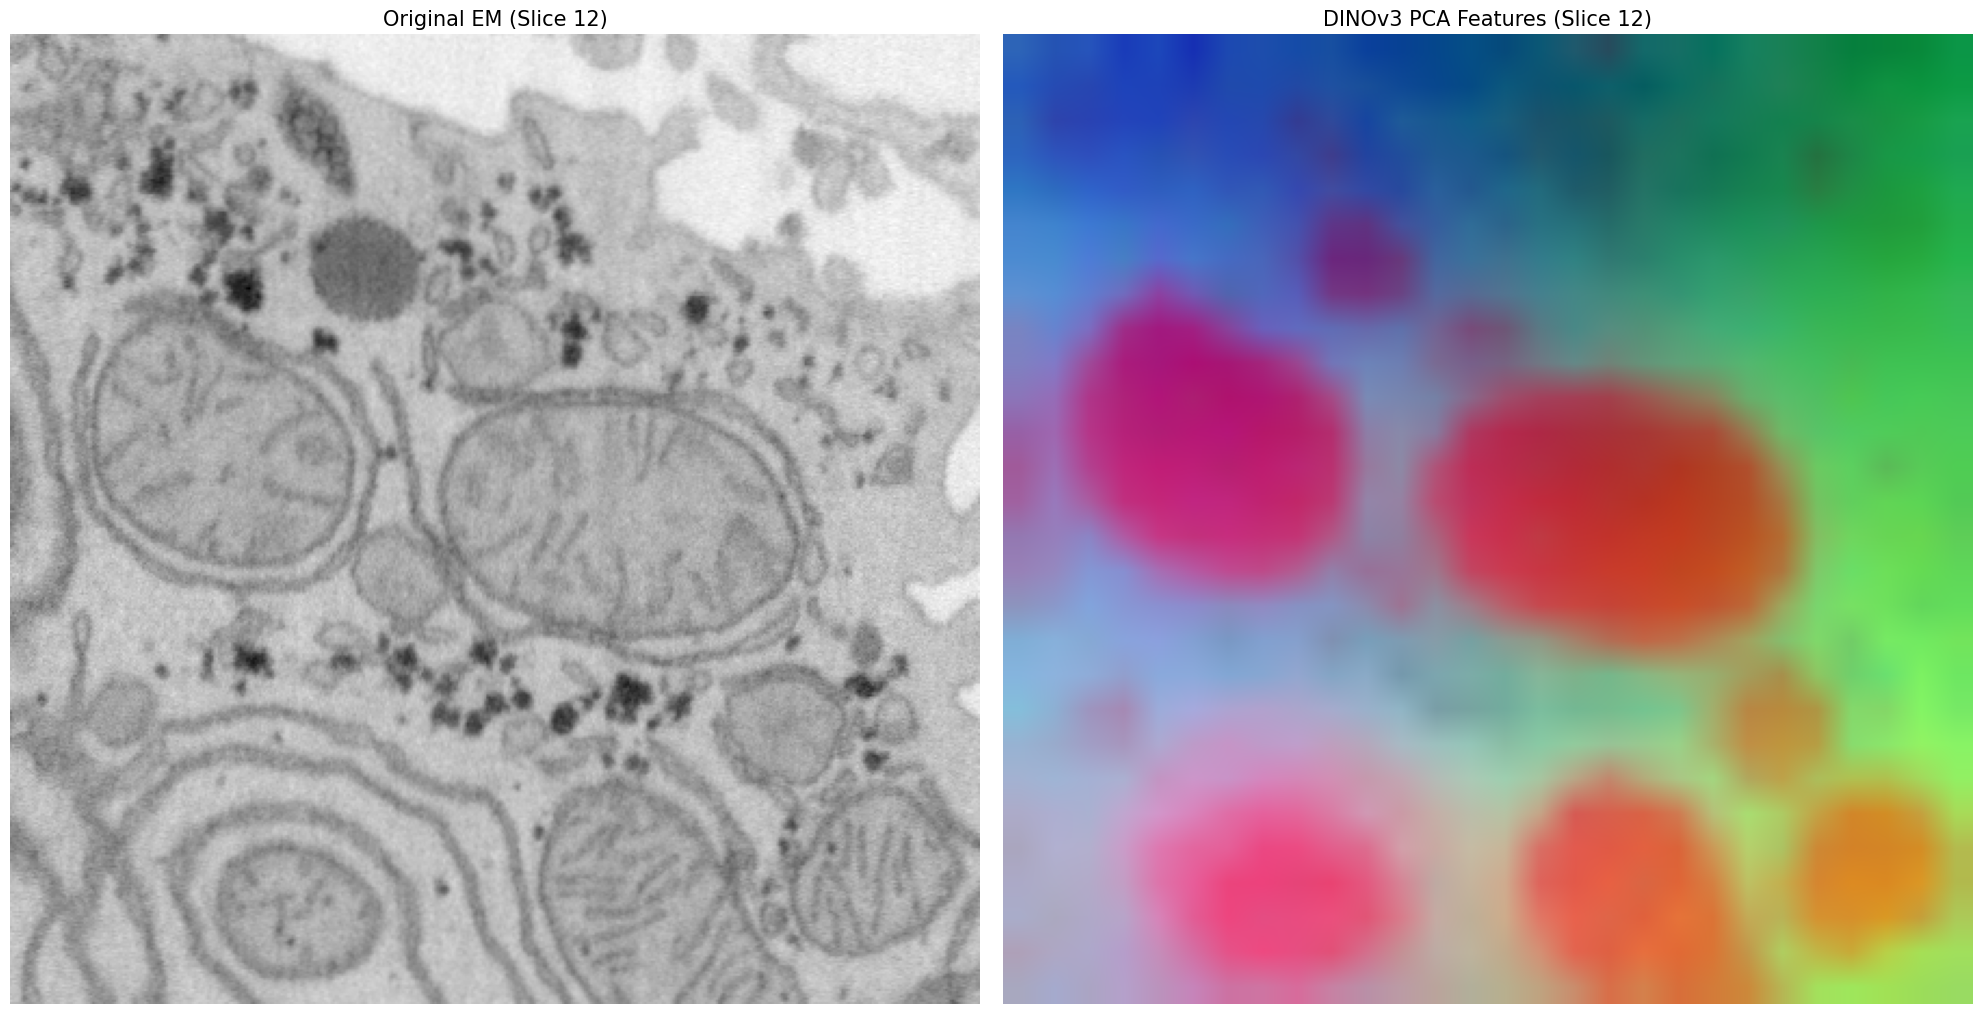

In [14]:
diagnosis.visualize_embeddings_pca(slice_idx= 12)

[2026-04-05 00:49:24,738: INFO: 1583408066: Computing PCA components...]
[2026-04-05 00:54:10,876: INFO: 1583408066: Comparison plot saved to OUTPUT/pca_s1.png]


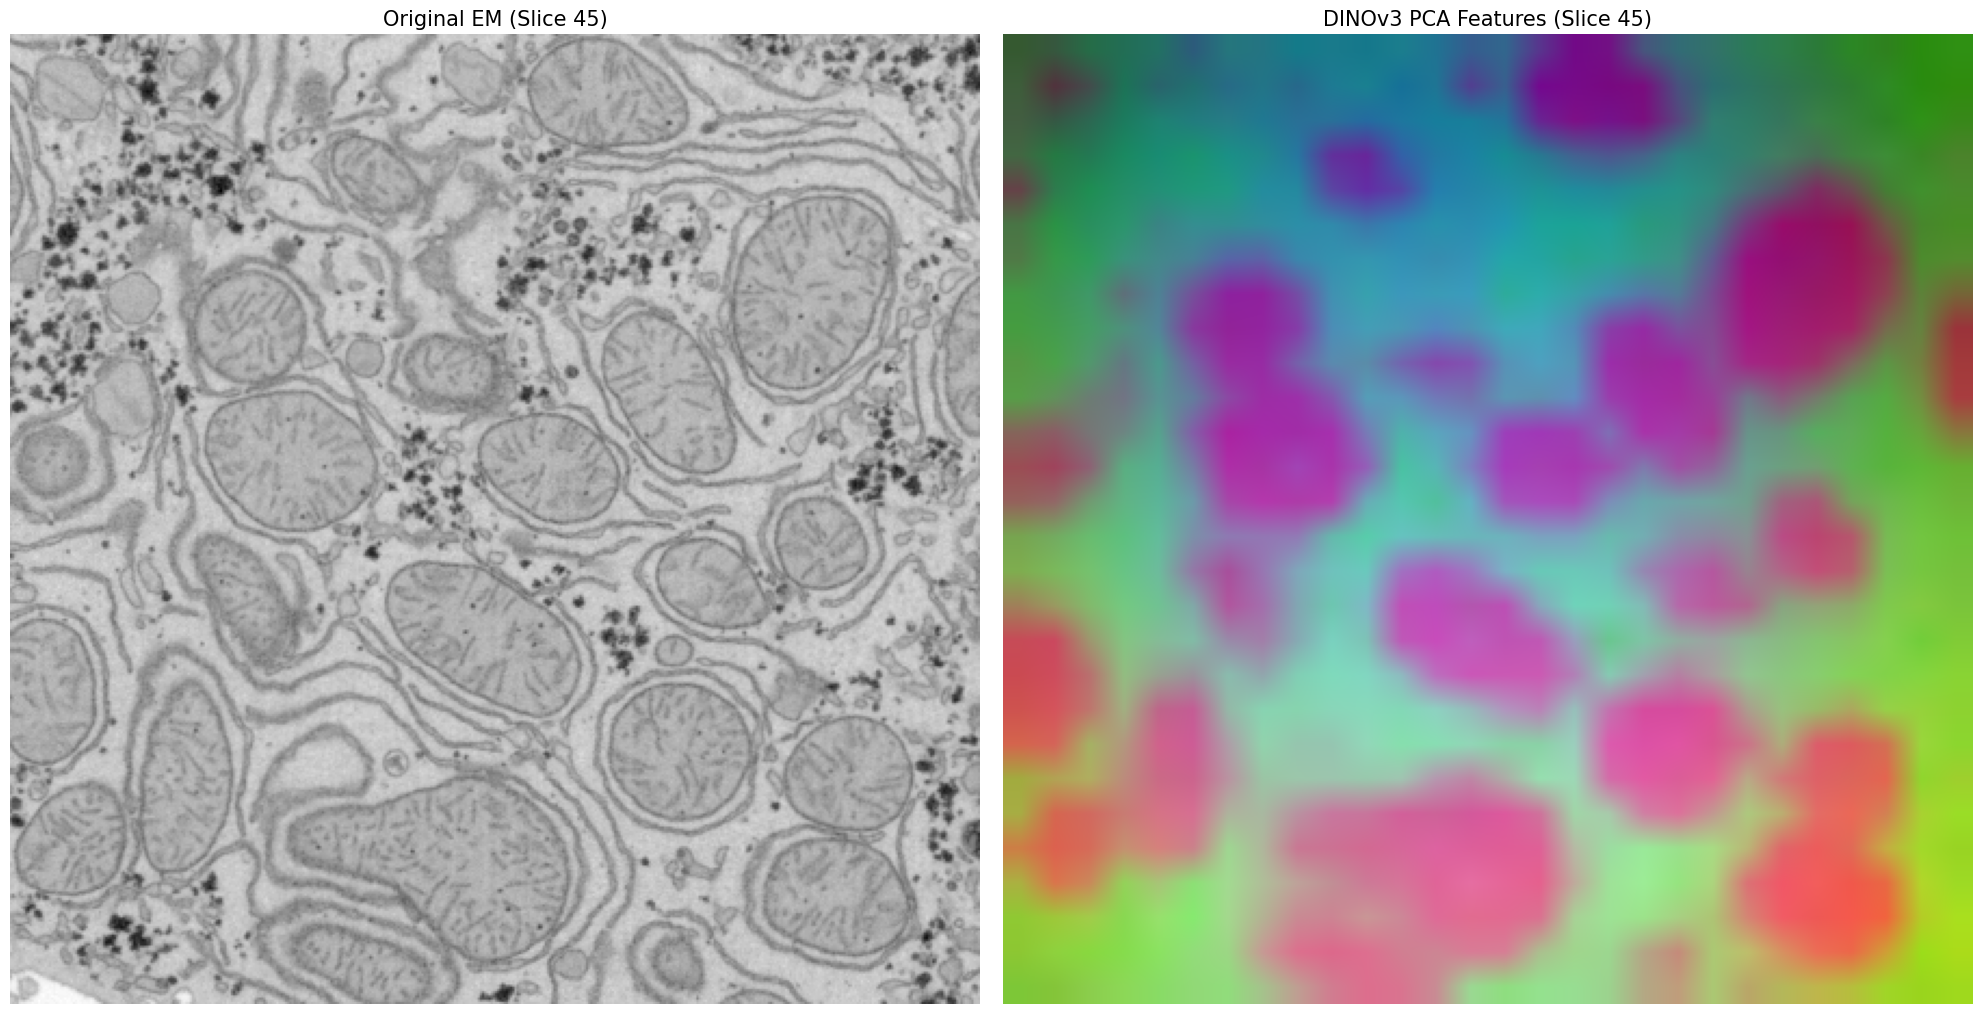

[2026-04-05 00:54:12,107: INFO: 1583408066: Memory fully cleared.Mac is now fresh for the next task!]


In [9]:
diagnosis.visualize_embeddings_pca(slice_idx= 45,filename='pca_s1.png')

8345

In [33]:
import torch

# 1. Initialize the model from the GitHub source
# This automatically handles the 'DNA' of the model (layers, attention, etc.)

model = torch.hub.load(
    'facebookresearch/dinov3', 
    'dinov3_vits16plus', 
    pretrained=False
)

# 2. Configure for your MacBook M2 Pro GPU (MPS)
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model.to(device)

# 3. Load your specific LVD-1689M weights
checkpoint = torch.load('artifacts/models/dinov3_vits16plus_pretrain_lvd1689m-4057cbaa.pth', map_location=device)
state_dict = checkpoint['model'] if 'model' in checkpoint else checkpoint
# Sometimes it's nested in 'teacher' for the distilled versions
if 'teacher' in state_dict:
    state_dict = state_dict['teacher']

# Remove 'module.' prefix if the weights were saved via DistributedDataParallel
state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)

model.eval()
print(f"DINOv3 S+ (29M) active on {device}")

Using cache found in /Users/kiranprasadjp/.cache/torch/hub/facebookresearch_dinov3_main


[2026-04-03 20:40:11,995: INFO: vision_transformer: using base=100 for rope new]
[2026-04-03 20:40:11,996: INFO: vision_transformer: using min_period=None for rope new]
[2026-04-03 20:40:11,996: INFO: vision_transformer: using max_period=None for rope new]
[2026-04-03 20:40:11,997: INFO: vision_transformer: using normalize_coords=separate for rope new]
[2026-04-03 20:40:11,997: INFO: vision_transformer: using shift_coords=None for rope new]
[2026-04-03 20:40:11,997: INFO: vision_transformer: using rescale_coords=2 for rope new]
[2026-04-03 20:40:11,997: INFO: vision_transformer: using jitter_coords=None for rope new]
[2026-04-03 20:40:11,998: INFO: vision_transformer: using dtype=fp32 for rope new]
[2026-04-03 20:40:11,998: INFO: vision_transformer: using swiglu layer as FFN]
DINOv3 S+ (29M) active on mps


In [14]:
params_dict = model.state_dict()

# 2. To see the names of the layers (useful for debugging):
print(params_dict.keys())

odict_keys(['cls_token', 'storage_tokens', 'mask_token', 'patch_embed.proj.weight', 'patch_embed.proj.bias', 'rope_embed.periods', 'blocks.0.norm1.weight', 'blocks.0.norm1.bias', 'blocks.0.attn.qkv.weight', 'blocks.0.attn.qkv.bias', 'blocks.0.attn.qkv.bias_mask', 'blocks.0.attn.proj.weight', 'blocks.0.attn.proj.bias', 'blocks.0.ls1.gamma', 'blocks.0.norm2.weight', 'blocks.0.norm2.bias', 'blocks.0.mlp.w1.weight', 'blocks.0.mlp.w1.bias', 'blocks.0.mlp.w2.weight', 'blocks.0.mlp.w2.bias', 'blocks.0.mlp.w3.weight', 'blocks.0.mlp.w3.bias', 'blocks.0.ls2.gamma', 'blocks.1.norm1.weight', 'blocks.1.norm1.bias', 'blocks.1.attn.qkv.weight', 'blocks.1.attn.qkv.bias', 'blocks.1.attn.qkv.bias_mask', 'blocks.1.attn.proj.weight', 'blocks.1.attn.proj.bias', 'blocks.1.ls1.gamma', 'blocks.1.norm2.weight', 'blocks.1.norm2.bias', 'blocks.1.mlp.w1.weight', 'blocks.1.mlp.w1.bias', 'blocks.1.mlp.w2.weight', 'blocks.1.mlp.w2.bias', 'blocks.1.mlp.w3.weight', 'blocks.1.mlp.w3.bias', 'blocks.1.ls2.gamma', 'blocks

In [4]:
from transformers import AutoImageProcessor

pretrained_model_name = "facebook/dinov3-vits16plus-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
print(processor.image_mean) # [0.485, 0.456, 0.406]
print(processor.image_std)  # [0.229, 0.224, 0.225]

(0.485, 0.456, 0.406)
(0.229, 0.224, 0.225)


In [ ]:

batch_size = 1
summary(model, input_size=(batch_size, 3, 448, 448))

Layer (type:depth-idx)                        Output Shape              Param #
DinoVisionTransformer                         [1, 384]                  2,304
├─PatchEmbed: 1-1                             [1, 28, 28, 384]          --
│    └─Conv2d: 2-1                            [1, 384, 28, 28]          295,296
│    └─Identity: 2-2                          [1, 784, 384]             --
├─RopePositionEmbedding: 1-2                  [784, 64]                 --
├─ModuleList: 1-25                            --                        (recursive)
│    └─SelfAttentionBlock: 2-3                [1, 789, 384]             --
│    │    └─LayerNorm: 3-1                    [1, 789, 384]             768
│    │    └─SelfAttention: 3-2                [1, 789, 384]             591,360
│    │    └─LayerScale: 3-3                   [1, 789, 384]             384
│    │    └─LayerNorm: 3-4                    [1, 789, 384]             768
│    │    └─SwiGLUFFN: 3-5                    [1, 789, 384]           

In [ ]:
from torchinfo import summary
import torch

input_size = (1, 3, 448, 448)

model_stats = summary(
    model, 
    input_size=input_size,
    col_names=["input_size", "output_size", "num_params", "mult_adds"],
    col_width=20,
    device="mps" 
)

print(model_stats)

Layer (type:depth-idx)                             Input Shape          Output Shape         Param #              Mult-Adds
DINOv3ViTModel                                     [1, 3, 448, 448]     [1, 384]             --                   --
├─DINOv3ViTEmbeddings: 1-1                         [1, 3, 448, 448]     [1, 789, 384]        2,304                --
│    └─Conv2d: 2-1                                 [1, 3, 448, 448]     [1, 384, 28, 28]     295,296              231,512,064
├─DINOv3ViTRopePositionEmbedding: 1-2              [1, 3, 448, 448]     [784, 64]            --                   --
├─DINOv3ViTEncoder: 1-3                            [1, 789, 384]        [1, 789, 384]        --                   --
│    └─ModuleList: 2-2                             --                   --                   --                   --
│    │    └─DINOv3ViTLayer: 3-1                    [1, 789, 384]        [1, 789, 384]        2,366,208            2,365,440
│    │    └─DINOv3ViTLayer: 3-2          

In [17]:
import torch
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = load_image(url)

pretrained_model_name = "facebook/dinov3-vits16plus-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
model = AutoModel.from_pretrained(
    pretrained_model_name, 
    device_map="auto", 
)

inputs = processor(images=image, return_tensors="pt").to(model.device)
with torch.inference_mode():
    outputs = model(**inputs)

pooled_output = outputs.pooler_output
print("Pooled output shape:", pooled_output.shape)


[2026-04-04 21:01:30,900: INFO: _client: HTTP Request: GET http://images.cocodataset.org/val2017/000000039769.jpg "HTTP/1.1 200 OK"]
[2026-04-04 21:01:31,102: INFO: _client: HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vits16plus-pretrain-lvd1689m/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"]
[2026-04-04 21:01:31,203: INFO: _client: HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vits16plus-pretrain-lvd1689m/resolve/main/preprocessor_config.json "HTTP/1.1 200 OK"]
[2026-04-04 21:01:31,256: INFO: _client: HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vits16plus-pretrain-lvd1689m/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"]
[2026-04-04 21:01:31,303: INFO: _client: HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vits16plus-pretrain-lvd1689m/resolve/main/preprocessor_config.json "HTTP/1.1 200 OK"]
[2026-04-04 21:01:31,381: INFO: _client: HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vits16plus-pretrain-

Loading weights:   0%|          | 0/235 [00:00<?, ?it/s]

Pooled output shape: torch.Size([1, 384])


In [22]:
dummy_rgb = torch.randn(2, 3, 448, 448).to(device).half()
print(f"Dummy Shape: {dummy_rgb.shape}")
model.to(device).half()
model.eval()

with torch.no_grad():
    # Run the dummy data
    out = model(dummy_rgb)

# List the Hugging Face Keys (Attributes)
print("\n--- Hugging Face Output Keys ---")
# This shows the available 'tabs' in the medical report we discussed
print(out.keys()) 

# Inspect the shapes of the specific keys
print(f"last_hidden_state: {out.last_hidden_state.shape}") # [2, 789, 384]
print(f"pooler_output:     {out.pooler_output.shape}")

Dummy Shape: torch.Size([2, 3, 448, 448])

--- Hugging Face Output Keys ---
odict_keys(['last_hidden_state', 'pooler_output'])
last_hidden_state: torch.Size([2, 789, 384])
pooler_output:     torch.Size([2, 384])


In [ ]:
import torch

# 1. Initialize the 'Skeleton' (Empty)
# We set pretrained=False because we already have the file locally
model = torch.hub.load(
    'facebookresearch/dinov3', 
    'dinov3_vits16plus', 
    pretrained=False
)
device = torch.device("mps")
checkpoint_path = "artifacts/models/dinov3_vits16plus_pretrain_lvd1689m-4057cbaa.pth"

# Map to MPS for M2 Pro speed
checkpoint = torch.load(checkpoint_path, map_location=device)

state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

model.load_state_dict(state_dict)
model.to(device).eval()

print("DINOv3 S+ Gated Model: Successfully Loaded.")

Using cache found in /Users/kiranprasadjp/.cache/torch/hub/facebookresearch_dinov3_main
/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DINOv3 S+ Gated Model: Successfully Loaded.


In [6]:
# 1. Get the list of all "Labels"
labels = list(state_dict.keys())

# 2. Print the first 10 to see the naming convention
print("--- First 10 Layer Labels ---")
for label in labels[:]:
    print(label)

# 3. Print the total count
print(f"\nTotal Number of Layers: {len(labels)}")

--- First 10 Layer Labels ---
cls_token
storage_tokens
mask_token
patch_embed.proj.weight
patch_embed.proj.bias
rope_embed.periods
blocks.0.norm1.weight
blocks.0.norm1.bias
blocks.0.attn.qkv.weight
blocks.0.attn.qkv.bias
blocks.0.attn.qkv.bias_mask
blocks.0.attn.proj.weight
blocks.0.attn.proj.bias
blocks.0.ls1.gamma
blocks.0.norm2.weight
blocks.0.norm2.bias
blocks.0.mlp.w1.weight
blocks.0.mlp.w1.bias
blocks.0.mlp.w2.weight
blocks.0.mlp.w2.bias
blocks.0.mlp.w3.weight
blocks.0.mlp.w3.bias
blocks.0.ls2.gamma
blocks.1.norm1.weight
blocks.1.norm1.bias
blocks.1.attn.qkv.weight
blocks.1.attn.qkv.bias
blocks.1.attn.qkv.bias_mask
blocks.1.attn.proj.weight
blocks.1.attn.proj.bias
blocks.1.ls1.gamma
blocks.1.norm2.weight
blocks.1.norm2.bias
blocks.1.mlp.w1.weight
blocks.1.mlp.w1.bias
blocks.1.mlp.w2.weight
blocks.1.mlp.w2.bias
blocks.1.mlp.w3.weight
blocks.1.mlp.w3.bias
blocks.1.ls2.gamma
blocks.2.norm1.weight
blocks.2.norm1.bias
blocks.2.attn.qkv.weight
blocks.2.attn.qkv.bias
blocks.2.attn.qkv.b

In [7]:
# This looks at the first word before the dot (e.g., 'blocks', 'patch_embed')
folders = sorted(list(set([k.split('.')[0] for k in state_dict.keys()])))

print("--- Top-Level Model Sections ('Folders') ---")
for folder in folders:
    # Count how many parameters are in each section
    count = len([k for k in state_dict.keys() if k.startswith(folder)])
    print(f"Folder: {folder:<15} | Layers: {count}")

--- Top-Level Model Sections ('Folders') ---
Folder: blocks          | Layers: 204
Folder: cls_token       | Layers: 1
Folder: mask_token      | Layers: 1
Folder: norm            | Layers: 2
Folder: patch_embed     | Layers: 2
Folder: rope_embed      | Layers: 1
Folder: storage_tokens  | Layers: 1


In [2]:
# 1. See the main 'folders' in the bundle
print("--- Checkpoint Bundle Keys ---")
print(checkpoint.keys())

# 2. Check the version or training progress if available
if 'epoch' in checkpoint:
    print(f"Model was trained for {checkpoint['epoch']} epochs.")
    
if 'arch' in checkpoint:
    print(f"Architecture defined in bundle: {checkpoint['arch']}")

--- Checkpoint Bundle Keys ---


NameError: name 'checkpoint' is not defined